# Pré-processamento do Dataset Opportunity (HAR)

**Objetivo:** Preparar os dados brutos do dataset *Opportunity* para modelos de Deep Learning (CNN, LSTM, etc.).

**Desafio:** O dataset é volumoso e o método tradicional de carregar todos os dados na RAM causa estouro de memória (OOM) no Google Colab.

**Estratégia Otimizada:**
1. **Processamento Incremental:** Utilização de `partial_fit` do Scikit-Learn para calcular estatísticas de normalização sem carregar tudo na memória.
2. **Streaming de Arquivos:** Carregamento, processamento e descarte de cada arquivo `.dat` individualmente.
3. **Redução de Precisão:** Conversão de `float64` para `float32` para economizar 50% de RAM.
4. **Janelamento:** Aplicação de *Sliding Window* com sobreposição.

**Configuração do Dataset:**
* **Frequência:** 30Hz
* **Janela (Window Size):** 64 amostras (~2.1 segundos)
* **Overlap:** 50% (Step Size = 32)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import glob
import os
import gc
import requests
import zipfile
from io import BytesIO
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from google.colab import drive

# 1. MONTAR DRIVE
drive.mount('/content/drive')

# --- CONFIGURAÇÕES ---
# Caminhos
DATA_PATH = '/content/drive/My Drive/2025/Estudos/Datasets/opportunity/OpportunityUCIDataset/dataset'
OUTPUT_PATH = '/content/drive/My Drive/2025/Estudos/Datasets/opportunity/opportunity_for_rp.npz'
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00226/OpportunityUCIDataset.zip"

# Hiperparâmetros de Janelamento
SAMPLING_RATE = 30
WINDOW_SIZE = 75
STEP_SIZE = 37

# Definição de Colunas (Feature 1-242, Label 249)
FEATURE_COLS = list(range(1, 243))
LABEL_COL = 249

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Análise Exploratória de Dados (EDA)

Antes de executar o pipeline completo, realizamos uma inspeção em um arquivo de amostra (`S1-Drill.dat`) para entender a qualidade dos dados.

**Insights dos Gráficos Gerados:**
1.  **Missing Values (Perda de Pacotes):** O gráfico de *Missing Values por Sensor* revela que diversos canais apresentam falhas na transmissão (valores nulos).
    * *Decisão:* Isso justifica o uso obrigatório de **interpolação linear** e preenchimento (`bfill`/`ffill`) na função de carga.
2.  **Desbalanceamento de Classes:** O histograma de classes mostra uma predominância massiva da classe "Null" (fundo/sem atividade) em comparação aos gestos específicos.
    * *Nota:* O modelo precisará lidar com esse desequilíbrio (ex: class weights).
3.  **Continuidade do Sinal:** A visualização do sensor bruto (ex: Canal 50) mostra que, apesar dos ruídos, o sinal possui continuidade temporal, validando o uso de janelamento deslizante.

Verificando arquivos em: /content/drive/My Drive/2025/Estudos/Datasets/opportunity/OpportunityUCIDataset/dataset
24 arquivos .dat encontrados.
Shape do arquivo: (51116, 250)


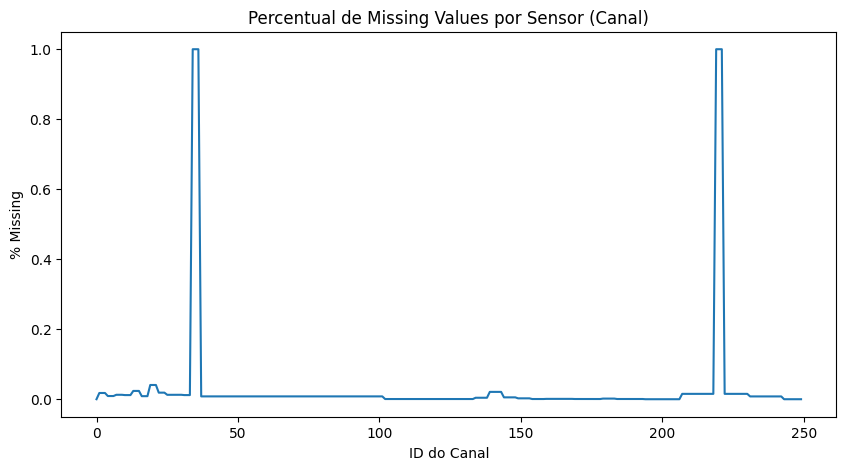

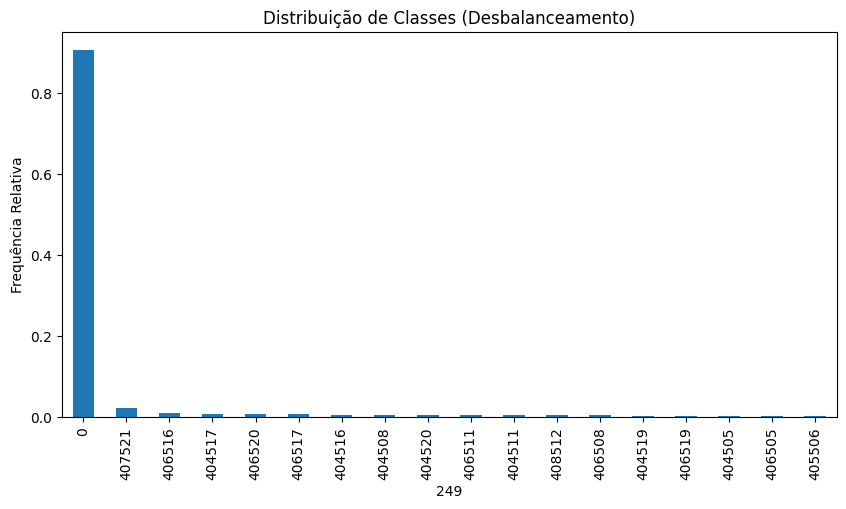

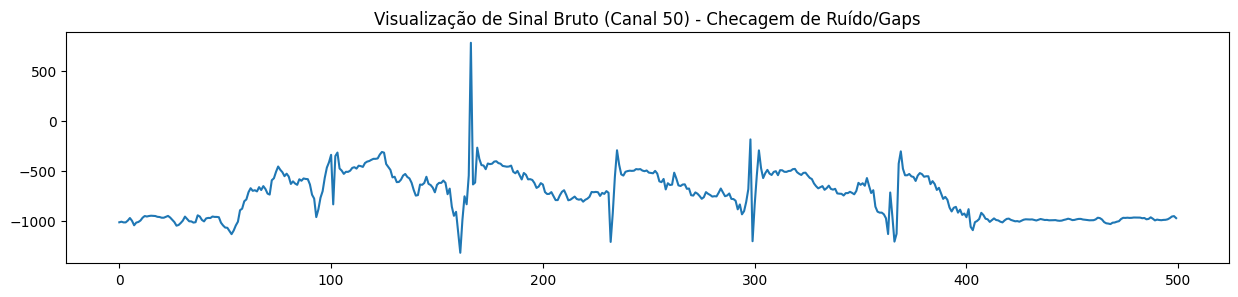

In [ ]:
print(f"Verificando arquivos em: {DATA_PATH}")
FILES = glob.glob(os.path.join(DATA_PATH, '*.dat'))

if not FILES:
    print(f"Nenhum arquivo .dat encontrado em {DATA_PATH}. Por favor, verifique se o caminho está correto no seu Google Drive.")
    print("Certifique-se de que o Drive está montado e que o diretório existe e contém arquivos .dat.")
else:
    print(f"{len(FILES)} arquivos .dat encontrados.")

def load_file(filepath):
    # O dataset Opportunity tem 242 colunas (ou 113 na versão Challenge)
    # As primeiras colunas são timestamp e anotações
    data = pd.read_csv(filepath, sep=' ', header=None)
    return data

# Carregar um arquivo de exemplo (S1-Drill) para inspeção rápida
df_sample = load_file(FILES[0]) if FILES else None

if df_sample is not None:
    print(f"Shape do arquivo: {df_sample.shape}")

    # 1. ANÁLISE DE MISSING VALUES
    missing_per_col = df_sample.isnull().mean()
    plt.figure(figsize=(10, 5))
    missing_per_col.plot(kind='line')
    plt.title("Percentual de Missing Values por Sensor (Canal)")
    plt.xlabel("ID do Canal")
    plt.ylabel("% Missing")
    plt.show()

    # 2. DISTRIBUIÇÃO DE CLASSES (Coluna 249 ou última col de label - ajuste conforme versão)
    # Opportunity (Challenge) usa a coluna 243 (Locomotion) e 244 (Gestures) geralmente.
    # Vamos assumir a coluna de Gestos (mais complexa).
    label_col = df_sample.shape[1] - 1
    class_counts = df_sample[label_col].value_counts(normalize=True)

    plt.figure(figsize=(10, 5))
    class_counts.plot(kind='bar')
    plt.title("Distribuição de Classes (Desbalanceamento)")
    plt.ylabel("Frequência Relativa")
    plt.show()

    # 3. CONTINUIDADE DO SINAL (Visualização de 500 amostras)
    plt.figure(figsize=(15, 3))
    plt.plot(df_sample.iloc[:500, 50]) # Exemplo: Sensor 50
    plt.title("Visualização de Sinal Bruto (Canal 50) - Checagem de Ruído/Gaps")
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
import glob
import os
import gc
import requests
import zipfile
from io import BytesIO
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from google.colab import drive

# --- DEFINIÇÃO DO SPLIT: LOPO (Leave-One-Person-Out) -para evitar que o modelo aprenda a biomecanica de uma pessoa ---
# O modelo APRENDE a física do Sujeito 1 e Sujeito 2
TRAIN_FILES = [
    'S1-ADL1.dat', 'S1-ADL2.dat', 'S1-ADL3.dat', 'S1-ADL4.dat', 'S1-ADL5.dat', 'S1-Drill.dat',
    'S2-ADL1.dat', 'S2-ADL2.dat', 'S2-ADL3.dat', 'S2-ADL4.dat', 'S2-ADL5.dat', 'S2-Drill.dat'
]

# O modelo CALIBRA (Early Stopping) em um corpo inédito: Sujeito 3
VAL_FILES = [
    'S3-ADL1.dat', 'S3-ADL2.dat', 'S3-ADL3.dat', 'S3-ADL4.dat', 'S3-ADL5.dat', 'S3-Drill.dat'
]

# O modelo é TESTADO na vida real em um corpo 100% isolado: Sujeito 4
TEST_FILES = [
    'S4-ADL1.dat', 'S4-ADL2.dat', 'S4-ADL3.dat', 'S4-ADL4.dat', 'S4-ADL5.dat', 'S4-Drill.dat'
]

# --- FUNÇÕES AUXILIARES ---
def download_dataset():
    if not os.path.exists('OpportunityUCIDataset'):
        print(" Baixando dataset Opportunity (pode demorar 2-3 min)...")
        r = requests.get(DATA_URL)
        z = zipfile.ZipFile(BytesIO(r.content))
        z.extractall()
        print(" Download concluído.")
    else:
        print(" Dataset encontrado localmente.")

def load_dat_file(filename):
    path = f'OpportunityUCIDataset/dataset/{filename}'
    if not os.path.exists(path):
        print(f" Arquivo não encontrado: {filename}")
        return None
    # Lê arquivo separado por espaços
    try:
        df = pd.read_csv(path, sep='\s+', header=None, engine='python')
        return df
    except Exception as e:
        print(f" Erro ao ler {filename}: {e}")
        return None

def clean_and_interpolate(df):
    # Interpolação Linear para preencher NaNs (comum em sensores wireless)
    # Forward fill e Backward fill para garantir zero NaNs nas bordas
    df = df.interpolate(method='linear', limit_direction='both')
    df = df.fillna(method='ffill').fillna(method='bfill')
    return df

def create_windows(X, y, window, step):
    Xs, ys = [], []
    for i in range(0, len(X) - window, step):
        v = X[i:(i + window)]
        lbl = y[i + window - 1] # Label do último frame da janela
        Xs.append(v)
        ys.append(lbl)
    return list(Xs), list(ys)

# --- EXECUÇÃO PRINCIPAL ---
def main():
    download_dataset()

    print("\n--- FASE 1: Carregamento e Processamento Inicial (Apenas Treino) ---")

    # Listas para guardar as janelas finais
    X_train_final, y_train_final = [], []
    X_val_final, y_val_final = [], []
    X_test_final, y_test_final = [], []

    print("\n--- FASE 2: Segmentação (Treino) ---")
    for f in TRAIN_FILES:
        print(f"   Segmentando {f}...", end="\r")
        df = load_dat_file(f)
        if df is None: continue
        df = clean_and_interpolate(df)

        raw_X = df.iloc[:, 1:243].values
        raw_y = df.iloc[:, 249].values

        # Normalização removida. Usando raw_X diretamente.
        # norm_X = scaler.transform(raw_X)

        wins_X, wins_y = create_windows(raw_X, raw_y, WINDOW_SIZE, STEP_SIZE)
        X_train_final.extend(wins_X)
        y_train_final.extend(wins_y)

    print(f"\n Treino processado: {len(X_train_final)} janelas.")

    print("\n--- FASE 2.5: Segmentação (Validação) ---")
    for f in VAL_FILES:
        print(f"   Segmentando {f}...", end="\r")
        df = load_dat_file(f)
        if df is None: continue
        df = clean_and_interpolate(df)

        raw_X = df.iloc[:, 1:243].values
        raw_y = df.iloc[:, 249].values

        # Normalização removida. Usando raw_X diretamente.
        # norm_X = scaler.transform(raw_X)

        wins_X, wins_y = create_windows(raw_X, raw_y, WINDOW_SIZE, STEP_SIZE)
        X_val_final.extend(wins_X)
        y_val_final.extend(wins_y)

    print(f"\n Validação processada: {len(X_val_final)} janelas.")

    print("\n--- FASE 3: Segmentação (Teste) ---")
    for f in TEST_FILES:
        print(f"   Segmentando {f}...", end="\r")
        df = load_dat_file(f)
        if df is None: continue
        df = clean_and_interpolate(df)

        raw_X = df.iloc[:, 1:243].values
        raw_y = df.iloc[:, 249].values

        # Normalização removida. Usando raw_X diretamente.
        # norm_X = scaler.transform(raw_X)

        wins_X, wins_y = create_windows(raw_X, raw_y, WINDOW_SIZE, STEP_SIZE)
        X_test_final.extend(wins_X)
        y_test_final.extend(wins_y)

    print(f"\n Teste processado: {len(X_test_final)} janelas.")

    print("\n--- FASE 4: Otimização e Salvamento ---")
    # Conversão para numpy arrays e float32
    X_train = np.array(X_train_final, dtype=np.float32)
    y_train = np.array(y_train_final, dtype=np.int32)
    X_val = np.array(X_val_final, dtype=np.float32) # NEW
    y_val = np.array(y_val_final, dtype=np.int32)   # NEW
    X_test = np.array(X_test_final, dtype=np.float32)
    y_test = np.array(y_test_final, dtype=np.int32)

    # Label Encoding (Mapear classes para 0..N)
    le = LabelEncoder()
    # Fit em tudo para garantir que todas as classes sejam mapeadas
    all_labels = np.concatenate([y_train, y_val, y_test]) # NEW
    le.fit(all_labels)

    y_train = le.transform(y_train)
    y_val = le.transform(y_val) # NEW
    y_test = le.transform(y_test)

    print(f"   Shape Final X_train: {X_train.shape}")
    print(f"   Shape Final X_val:   {X_val.shape}") # NEW
    print(f"   Shape Final X_test:  {X_test.shape}")

    np.savez_compressed(
        OUTPUT_PATH,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val, # NEW
        X_test=X_test, y_test=y_test,
        classes=le.classes_
    )
    print(f"\n SUCESSO. Arquivo salvo em: {OUTPUT_PATH}")

if __name__ == "__main__":
    main()

<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8856/727159067.py:48: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(path, sep='\s+', header=None, engine='python')


 Baixando dataset Opportunity (pode demorar 2-3 min)...
 Download concluído.

--- FASE 1: Carregamento e Processamento Inicial (Apenas Treino) ---

--- FASE 2: Segmentação (Treino) ---


/tmp/ipykernel_8856/727159067.py:58: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


/tmp/ipykernel_8856/727159067.py:58: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


/tmp/ipykernel_8856/727159067.py:58: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


...

/tmp/ipykernel_8856/727159067.py:58: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


/tmp/ipykernel_8856/727159067.py:58: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


/tmp/ipykernel_8856/727159067.py:58: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


/tmp/ipykernel_8856/727159067.py:58: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')



 Teste processado: 5198 janelas.

--- FASE 4: Otimização e Salvamento ---
   Shape Final X_train: (12411, 75, 242)
   Shape Final X_val:   (5852, 75, 242)
   Shape Final X_test:  (5198, 75, 242)

 SUCESSO. Arquivo salvo em: /content/drive/My Drive/2025/Estudos/Datasets/opportunity/opportunity_for_rp.npz
